In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
print(os.getcwd())
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/working
/kaggle/input/ana-verse-2-0-h/train.parquet
/kaggle/input/ana-verse-2-0-h/sample_submission.parquet
/kaggle/input/ana-verse-2-0-h/test.parquet


In [82]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score,
    make_scorer
)

def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average="macro")
    f1_per_class = f1_score(y_val, y_pred, average=None)

    print("Accuracy:", acc)
    print("F1 Score (macro):", f1_macro)
    print("F1 Score (per class):", f1_per_class)
    print("\nClassification Report:\n")
    print(classification_report(y_val, y_pred))

import warnings
warnings.filterwarnings("ignore")


In [88]:
import pandas as pd

train_df = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/train.parquet")
test_df  = pd.read_parquet("/kaggle/input/ana-verse-2-0-h/test.parquet")

print(train_df.shape)
train_df.head()




(1639424, 7)


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [7]:

print(test_df.shape)
test_df.head()

(409856, 7)


,ID,Date,X1,X2,X3,X4,X5
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213


In [ ]:
#EXPLORATORY DATA ANALYSIS

In [8]:
train_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


In [9]:

train_df.describe()


,Date,X1,X2,X3,X4,X5
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00
std,NaN,1.391992e-01,1.342811e-02,2.346156e+35,5.812988e+31,1.304814e+00


In [10]:
train_df.columns

Index(['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target'], dtype='object')

In [ ]:
#MISSING VALUES

In [12]:
missing = train_df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: float64)

In [ ]:
#Target Distribution

In [13]:
train_df.columns

Index(['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target'], dtype='object')

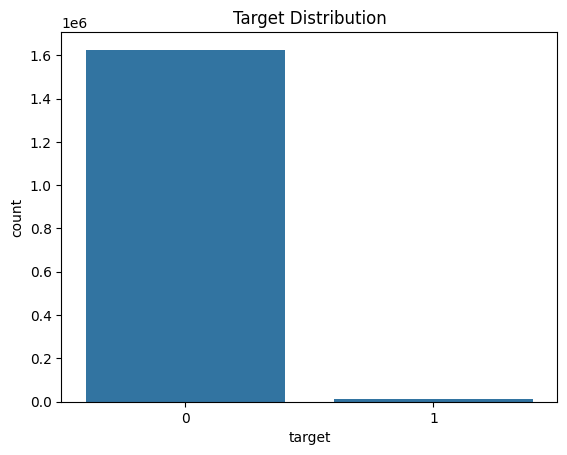

In [14]:
sns.countplot(x="target", data=train_df)
plt.title("Target Distribution")
plt.show()

In [ ]:
#FeatureEngineering & Corelation

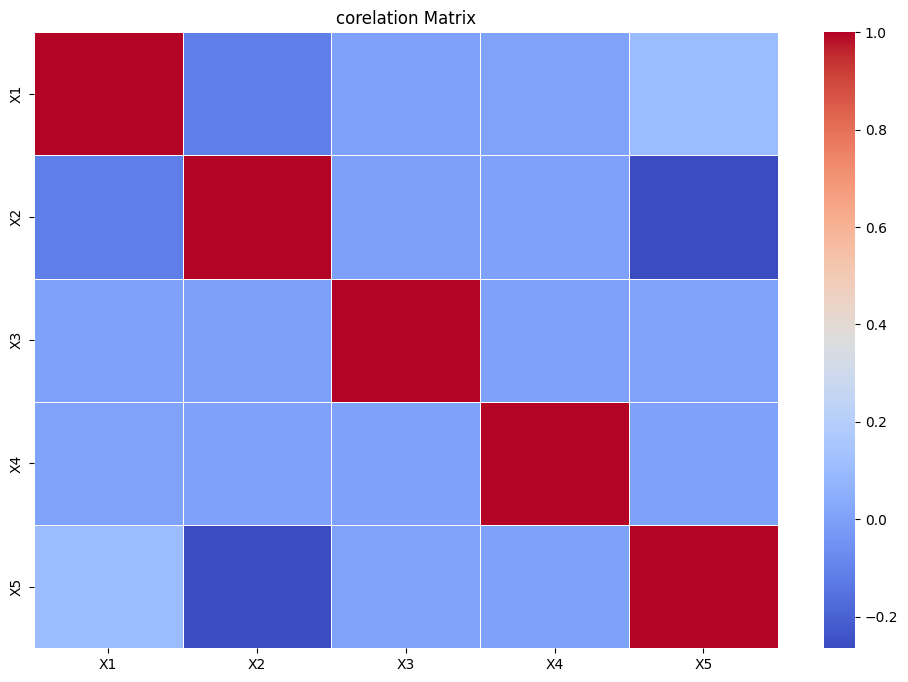

In [15]:
plt.figure(figsize=(12,8))
cor=train_df.corr(numeric_only=True)
sns.heatmap(cor,cmap="coolwarm",linewidths=0.5)
plt.title("corelation Matrix")
plt.show()

In [ ]:
#Train-Validation Split

In [90]:
y = train_df["target"].astype(int)
X = train_df.drop(columns=["target"])


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [18]:
num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include=["object","category"]).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])


In [19]:
log_reg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

log_reg.fit(X_train, y_train)
evaluate_model(log_reg, X_val, y_val)


Accuracy: 0.8616283148054958
F1 Score (macro): 0.5115570105498817
F1 Score (per class): [0.92506623 0.09804779]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.93    325077
           1       0.05      0.88      0.10      2808

    accuracy                           0.86    327885
   macro avg       0.53      0.87      0.51    327885
weighted avg       0.99      0.86      0.92    327885



In [20]:
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(class_weight="balanced", max_iter=5000))
])

svm.fit(X_train, y_train)
evaluate_model(svm, X_val, y_val)


Accuracy: 0.8575567653293076
F1 Score (macro): 0.5092235707119314
F1 Score (per class): [0.92268907 0.09575807]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.92    325077
           1       0.05      0.88      0.10      2808

    accuracy                           0.86    327885
   macro avg       0.52      0.87      0.51    327885
weighted avg       0.99      0.86      0.92    327885



In [21]:
from sklearn.neighbors import KNeighborsClassifier
knn = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        algorithm="ball_tree"
    ))
])

knn.fit(X_train, y_train)
evaluate_model(knn, X_val, y_val)


Accuracy: 0.991988044588804
F1 Score (macro): 0.6230219377950181
F1 Score (per class): [0.99597251 0.25007137]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    325077
           1       0.63      0.16      0.25      2808

    accuracy                           0.99    327885
   macro avg       0.81      0.58      0.62    327885
weighted avg       0.99      0.99      0.99    327885



In [26]:
dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

dt.fit(X_train, y_train)
evaluate_model(dt, X_val, y_val)


Accuracy: 0.8679781020784726
F1 Score (macro): 0.5154230354451562
F1 Score (per class): [0.92875107 0.102095  ]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.87      0.93    325077
           1       0.05      0.88      0.10      2808

    accuracy                           0.87    327885
   macro avg       0.53      0.87      0.52    327885
weighted avg       0.99      0.87      0.92    327885



In [ ]:
#XGBOOST CLASSIFIER

In [86]:
xgb= Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1]),
        random_state=42,
        n_jobs=-1
    ))
])


In [91]:
f1_anomaly = make_scorer(f1_score, pos_label=1)

cv_f1 = cross_val_score(
    xgb,
    X,
    y,
    scoring=f1_anomaly,
    cv=5,
    n_jobs=-1
)

print("CV F1 Scores:", cv_f1)
print("Mean CV F1:", cv_f1.mean())


CV F1 Scores: [0.05047412 0.09497445 0.15096101 0.15436121 0.17672499]
Mean CV F1: 0.12549915638857892


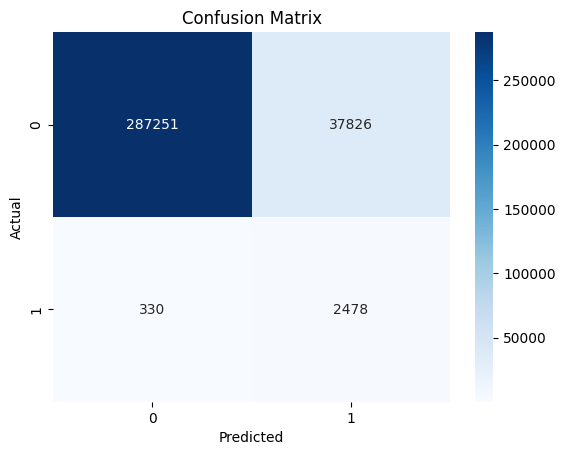

In [100]:

xgb.fit(X_train, y_train)
y_val_pred = xgb.predict(X_val)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [102]:
xgb.fit(X, y)

test_preds = xgb.predict(test_df)

submission = pd.DataFrame({
    "id": test_df.index,
    "target": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,target
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
